In [50]:
import numpy as np
import pandas as pd
import re

In [51]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [52]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [53]:
df.duplicated().sum()

np.int64(122)

In [54]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,servant room,10.0,North-East,1 to 5 Year Old,"['Paras Trinity Shopping Mall', 'Golf Course Extension Road', 'Heritage Xperiential Learning School', 'IILM University, Gurugram', 'Swastik Multispeciality Hospital', 'Indira Gandhi International Airport', 'AIPL Business Co Working Space', 'Lemon Tree Hotel Sector 60', 'SkyJumper Trampoline Park', 'DLF Golf and Country Club', 'SCC Drive-In Cinema']","['4 Fan', '15 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",J69118026


## 1. areaWithType

In [55]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
63,1.00,1100.0,Super Built up area 1100(102.19 sq.m.)
2566,1.10,1785.0,Super Built up area 1785(165.83 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1500 sq.ft. (139.35 sq.m.)
2714,1.58,1733.0,Super Built up area 1700(157.94 sq.m.)
2313,4.50,360.0,Built Up area: 360 (33.45 sq.m.)
2403,2.25,918.0,Plot area 102(85.28 sq.m.)Built Up area: 90 sq.yards (75.25 sq.m.)Carpet area: 85 sq.yards (71.07 sq.m.)


In [56]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [57]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [58]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [59]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [60]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
902,2.20,flat,2195.0,Super Built up area 2095(194.63 sq.m.)Built Up area: 1860 sq.ft. (172.8 sq.m.),2095.0,1860.0,NaN
1902,1.13,flat,1764.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),1760.0,1186.0,1130.0
1523,0.97,flat,1100.0,Super Built up area 1385(128.67 sq.m.)Built Up area: 1200 sq.ft. (111.48 sq.m.)Carpet area: 1100 sq.ft. (102.19 sq.m.),1385.0,1200.0,1100.0
2375,0.90,flat,1271.0,Super Built up area 1200(111.48 sq.m.),1200.0,NaN,NaN
214,1.65,house,900.0,Built Up area: 900 (83.61 sq.m.),NaN,900.0,NaN


In [61]:
df.duplicated().sum()

np.int64(122)

In [62]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [63]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,9.5,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
3,1.6,house,892.0,Plot area 892(82.87 sq.m.),NaN,NaN,NaN
9,25.0,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,NaN,NaN
10,18.0,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
15,8.5,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [64]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
property_id               0
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [65]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [66]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,9.5,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
3,1.6,house,892.0,Plot area 892(82.87 sq.m.),NaN,NaN,NaN
9,25.0,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,NaN,NaN
10,18.0,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
15,8.5,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [67]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [68]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [69]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [70]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,9.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.00,NaN
3,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
9,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,1000.00,NaN
10,18.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
15,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
23,10.85,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.00,NaN
26,0.95,house,450.0,Plot area 450(41.81 sq.m.),NaN,450.00,NaN
38,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
48,11.50,house,4680.0,Plot area 520(434.79 sq.m.),NaN,520.00,NaN
49,5.70,house,2518.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN


In [71]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [72]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [73]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,9.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,2367.00,NaN
3,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
9,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,1000.00,NaN
10,18.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.00,NaN
15,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
23,10.85,house,2844.0,Plot area 316(264.22 sq.m.),NaN,2844.00,NaN
26,0.95,house,450.0,Plot area 450(41.81 sq.m.),NaN,450.00,NaN
38,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
48,11.50,house,4680.0,Plot area 520(434.79 sq.m.),NaN,4680.00,NaN
49,5.70,house,2518.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN


In [74]:
# update the original dataframe
df.update(all_nan_df)

In [75]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
property_id               0
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [76]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id,super_built_up_area,built_up_area,carpet_area
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,servant room,10.0,North-East,1 to 5 Year Old,"['Paras Trinity Shopping Mall', 'Golf Course Extension Road', 'Heritage Xperiential Learning School', 'IILM University, Gurugram', 'Swastik Multispeciality Hospital', 'Indira Gandhi International Airport', 'AIPL Business Co Working Space', 'Lemon Tree Hotel Sector 60', 'SkyJumper Trampoline Park', 'DLF Golf and Country Club', 'SCC Drive-In Cinema']","['4 Fan', '15 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",J69118026,5514.0,NaN,NaN
1,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,store room,4.0,NaN,0 to 1 Year Old,"['Huda city centre metro station', 'Icici bank ATM', 'State bank of india ATM', 'Axis bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Shivam Hospital Gurgaon', 'Dispencery', 'Ahmed Hospital Multi Speciality', 'Centre For Sight Gurgaon Sector 29', 'Dayal Eye & Maternity Centre', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Hdfc bank', 'Bar and restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Cafe Coffee Day', 'Raj Restaurant', '32nd Milestone', 'Darbar', 'Dhabba', ""Hops 'N' Brew"", 'Pizza Hut', 'Spaghetti Kitchen & Bar', ""Domino's Pizza"", ""McDonald's"", 'Tocpao', 'Beer & Whisky Bar', 'Zura', 'The Oriental Bloom Chinese and Thai', 'CR Model Public School', 'St. Angels Jr', 'Salvan Public School', 'School of Inspired Leadership SOIL', 'Manav Rachna School', 'St. Angels Sr', 'Manav Rachna Swimming Pool']","['5 Wardrobe', '1 Water Purifier', '1 Exhaust Fan', '5 Geyser', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Water purifier', 'False Ceiling Lighting', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Spacious Interiors']",G69453034,NaN,2367.0,NaN
2,flat,m3m golf hills,sector 79,1.45,10211.0,1420.0,Carpet area: 1420 (131.92 sq.m.),2,2,3 Balconies,not available,15.0,NaN,Jul 2027,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao Dhaba', ""McDonald's""]",[],NaN,D69857690,NaN,NaN,1420.0
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,not available,2.0,NaN,10+ Year Old,"['State bank of india ATM', 'Axis bank ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Dispencery', 'Sukhmani Hospital Pvt. Ltd', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Shivam Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Ahmed Hospital Multi Speci

## 2.additionalRoom

In [77]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
pooja room,st

In [78]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [79]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
50,study room,1,0,0,0,0
1558,not available,0,0,0,0,0
2215,"servant room,others",0,1,0,0,1
823,pooja room,0,0,0,1,0
2380,"pooja room,servant room",0,1,0,1,0


In [80]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,servant room,10.0,North-East,1 to 5 Year Old,"['Paras Trinity Shopping Mall', 'Golf Course Extension Road', 'Heritage Xperiential Learning School', 'IILM University, Gurugram', 'Swastik Multispeciality Hospital', 'Indira Gandhi International Airport', 'AIPL Business Co Working Space', 'Lemon Tree Hotel Sector 60', 'SkyJumper Trampoline Park', 'DLF Golf and Country Club', 'SCC Drive-In Cinema']","['4 Fan', '15 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",J69118026,5514.0,NaN,NaN,0,1,0,0,0
1,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,store room,4.0,NaN,0 to 1 Year Old,"['Huda city centre metro station', 'Icici bank ATM', 'State bank of india ATM', 'Axis bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Shivam Hospital Gurgaon', 'Dispencery', 'Ahmed Hospital Multi Speciality', 'Centre For Sight Gurgaon Sector 29', 'Dayal Eye & Maternity Centre', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Hdfc bank', 'Bar and restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Cafe Coffee Day', 'Raj Restaurant', '32nd Milestone', 'Darbar', 'Dhabba', ""Hops 'N' Brew"", 'Pizza Hut', 'Spaghetti Kitchen & Bar', ""Domino's Pizza"", ""McDonald's"", 'Tocpao', 'Beer & Whisky Bar', 'Zura', 'The Oriental Bloom Chinese and Thai', 'CR Model Public School', 'St. Angels Jr', 'Salvan Public School', 'School of Inspired Leadership SOIL', 'Manav Rachna School', 'St. Angels Sr', 'Manav Rachna Swimming Pool']","['5 Wardrobe', '1 Water Purifier', '1 Exhaust Fan', '5 Geyser', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Water purifier', 'False Ceiling Lighting', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Spacious Interiors']",G69453034,NaN,2367.0,NaN,0,0,1,0,0
2,flat,m3m golf hills,sector 79,1.45,10211.0,1420.0,Carpet area: 1420 (131.92 sq.m.),2,2,3 Balconies,not available,15.0,NaN,Jul 2027,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao Dhaba', ""McDonald's""]",[],NaN,D69857690,NaN,NaN,1420.0,0,0,0,0,0
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,not available,2.0,NaN,10+ Year Old,"['State bank of india ATM', 'Axis bank ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Dispencery', 'Sukhmani Hospital Pvt. Ltd', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Shivam Hos

## 3.agePossession

In [81]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Nov 2023                 5
Sep 2023                 4
Aug 2024                 4
Jul 2024                 4
Oct 2023                 4
By 2025                  4
May 2024                 3
Jan 2025                 3
Feb 2024                 3
Nov 2024                 3
Jul 2027                 2
Jul 2025                 2
Sep 2025                 2
Jun 2027                 2
Mar 2025                 2
Apr 2026                 2
By 2027                  2
Oct 2025                 2
Jan 2026      

In [82]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [83]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [84]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [85]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,servant room,10.0,North-East,Relatively New,"['Paras Trinity Shopping Mall', 'Golf Course Extension Road', 'Heritage Xperiential Learning School', 'IILM University, Gurugram', 'Swastik Multispeciality Hospital', 'Indira Gandhi International Airport', 'AIPL Business Co Working Space', 'Lemon Tree Hotel Sector 60', 'SkyJumper Trampoline Park', 'DLF Golf and Country Club', 'SCC Drive-In Cinema']","['4 Fan', '15 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",J69118026,5514.0,NaN,NaN,0,1,0,0,0
1,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,store room,4.0,NaN,New Property,"['Huda city centre metro station', 'Icici bank ATM', 'State bank of india ATM', 'Axis bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Shivam Hospital Gurgaon', 'Dispencery', 'Ahmed Hospital Multi Speciality', 'Centre For Sight Gurgaon Sector 29', 'Dayal Eye & Maternity Centre', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Hdfc bank', 'Bar and restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Cafe Coffee Day', 'Raj Restaurant', '32nd Milestone', 'Darbar', 'Dhabba', ""Hops 'N' Brew"", 'Pizza Hut', 'Spaghetti Kitchen & Bar', ""Domino's Pizza"", ""McDonald's"", 'Tocpao', 'Beer & Whisky Bar', 'Zura', 'The Oriental Bloom Chinese and Thai', 'CR Model Public School', 'St. Angels Jr', 'Salvan Public School', 'School of Inspired Leadership SOIL', 'Manav Rachna School', 'St. Angels Sr', 'Manav Rachna Swimming Pool']","['5 Wardrobe', '1 Water Purifier', '1 Exhaust Fan', '5 Geyser', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Water purifier', 'False Ceiling Lighting', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Spacious Interiors']",G69453034,NaN,2367.0,NaN,0,0,1,0,0
2,flat,m3m golf hills,sector 79,1.45,10211.0,1420.0,Carpet area: 1420 (131.92 sq.m.),2,2,3 Balconies,not available,15.0,NaN,Under Construction,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao Dhaba', ""McDonald's""]",[],NaN,D69857690,NaN,NaN,1420.0,0,0,0,0,0
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,not available,2.0,NaN,Old Property,"['State bank of india ATM', 'Axis bank ATM', 'Icici bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Standard chartered ATM', 'Hdfc bank ATM', 'Dispencery', 'Sukhmani Hospital Pvt. Ltd', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Medanta', 'Shiv

## 4.furnishDetails

In [86]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
236,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '10 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
2615,NaN,"['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1904,[],"['Swimming Pool', 'Visitor Parking']"
2390,"['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '2 Geyser', '10 Light', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2993,NaN,NaN


In [87]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\abhay\AppData\Local\Temp\ipykernel_24416\2118040236.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [88]:
furnishings_df.shape

(3803, 19)

In [89]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\abhay\AppData\Local\Temp\ipykernel_24416\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [90]:
furnishings_df.sample(5)

,Geyser,Water Purifier,Microwave,Modular Kitchen,Washing Machine,Fridge,Wardrobe,Bed,Light,Dining Table,AC,Stove,Exhaust Fan,Chimney,Fan,Sofa,Curtains,TV
2148,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1120,5,0,0,1,0,1,5,4,5,1,5,1,1,1,6,1,1,3
2232,5,1,0,1,0,0,5,0,9,0,6,0,1,0,4,0,0,0
1483,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3215,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [91]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [92]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [93]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

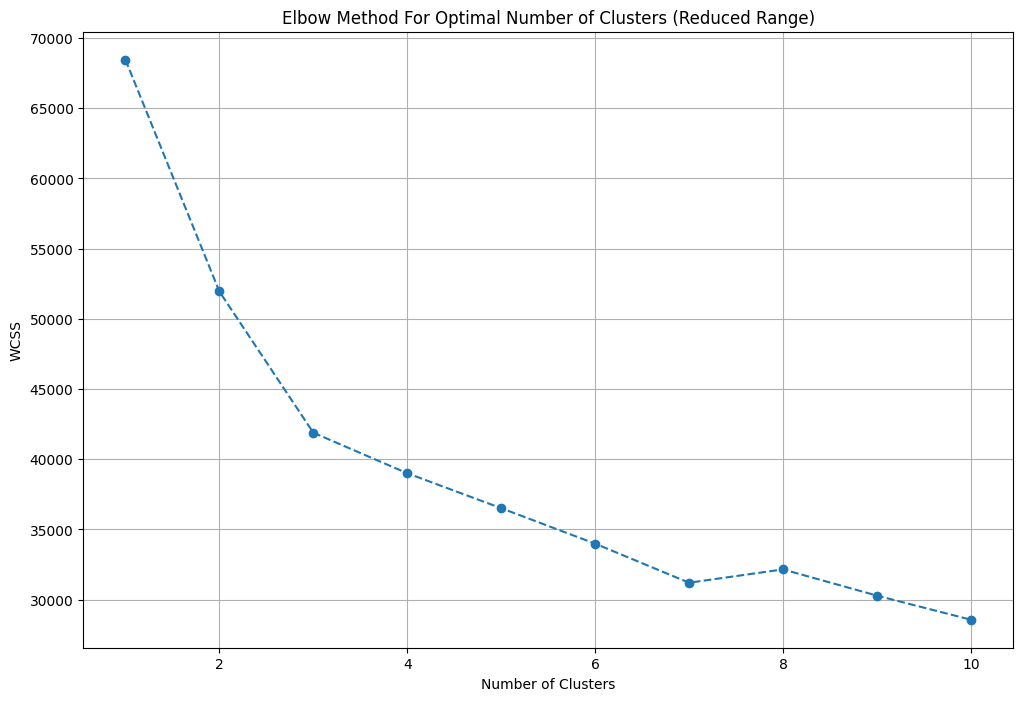

In [94]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [95]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [96]:
df = df.iloc[:,:-18]

In [97]:
df['furnishing_type'] = cluster_assignments

In [98]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2026,[],2
3207,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",2
186,NaN,2
3603,NaN,2
2007,NaN,2


## 5.features

In [99]:
df[['society','features']].sample(5)

,society,features
2187,umang monsoon breeze,"['Piped-gas', 'Natural Light']"
3065,emaar mgf marbella,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Park', 'Piped-gas', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Waste Disposal', 'Rain Water Harvesting']"
458,experion windchants,"['Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1104,m3m skywalk,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3368,conscient heritage max,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [100]:
df['features'].isnull().sum()

np.int64(635)

In [101]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [102]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [103]:
temp_df = df[df['features'].isnull()]

In [104]:
temp_df.shape

(635, 27)

In [105]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [106]:
df.loc[temp_df.index,'features'] = x.values

In [107]:
df['features'].isnull().sum()

np.int64(481)

In [108]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [109]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [110]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1145,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3258,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1519,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
886,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0


In [111]:
features_binary_df.shape

(3803, 130)

In [112]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

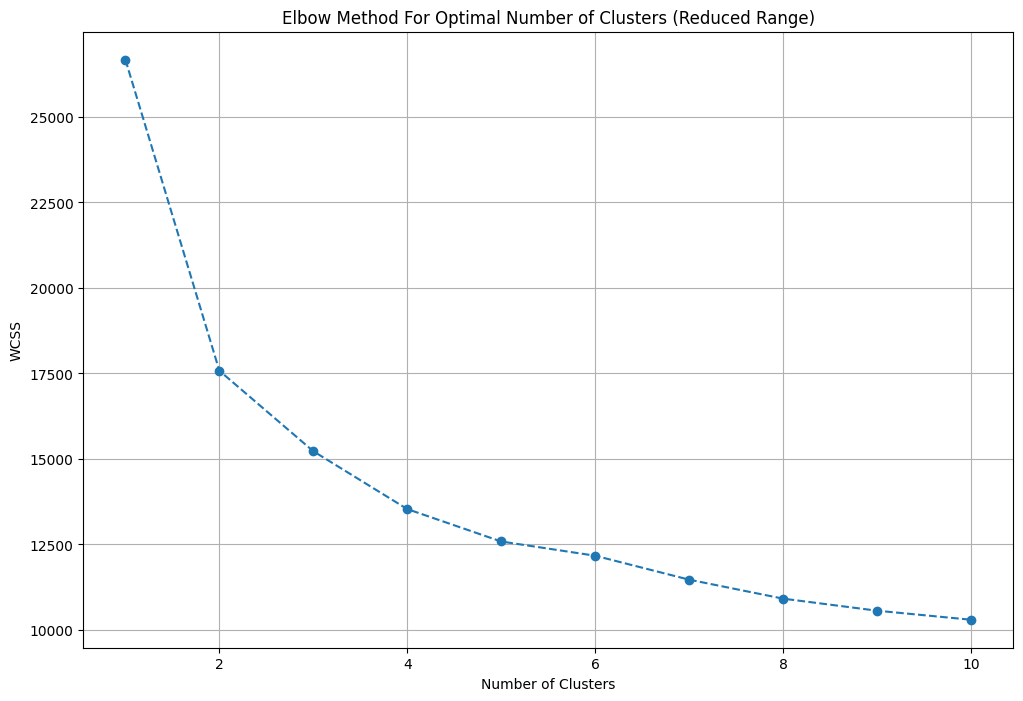

In [113]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [114]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [115]:
df['luxury_score'] = luxury_score

In [116]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,servant room,10.0,North-East,Relatively New,"['Paras Trinity Shopping Mall', 'Golf Course Extension Road', 'Heritage Xperiential Learning School', 'IILM University, Gurugram', 'Swastik Multispeciality Hospital', 'Indira Gandhi International Airport', 'AIPL Business Co Working Space', 'Lemon Tree Hotel Sector 60', 'SkyJumper Trampoline Park', 'DLF Golf and Country Club', 'SCC Drive-In Cinema']","['4 Fan', '15 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",J69118026,5514.0,NaN,NaN,0,1,0,0,0,0,"[Security / Fire Alarm, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Piped-gas, Internet/wi-fi connectivity, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",153
1,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,store room,4.0,NaN,New Property,"['Huda city centre metro station', 'Icici bank ATM', 'State bank of india ATM', 'Axis bank ATM', 'Icici ATM', 'Citi bank ATM', 'Axis bank ATM', 'Hdfc ATM', 'Axis bank ATM', 'Hdfc bank ATM', 'State bank of india ATM', 'Shivam Hospital Gurgaon', 'Dispencery', 'Ahmed Hospital Multi Speciality', 'Centre For Sight Gurgaon Sector 29', 'Dayal Eye & Maternity Centre', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Dr. Naval Mendiratta', 'Gardian Pharmacy', 'City Medical', 'Gardian Pharmacy', 'Pernod Ricard Charitable Dispensary', 'IBP Petrol Pump', 'Hdfc bank', 'Bar and restaurant', 'Fast food', 'Fast Food', 'Om Sweets', 'Cafe Coffee Day', 'Raj Restaurant', '32nd Milestone', 'Darbar', 'Dhabba', ""Hops 'N' Brew"", 'Pizza Hut', 'Spaghetti Kitchen & Bar', ""Domino's Pizza"", ""McDonald's"", 'Tocpao', 'Beer & Whisky Bar', 'Zura', 'The Oriental Bloom Chinese and Thai', 'CR Model Public School', 'St. Angels Jr', 'Salvan Public School', 'School of Inspired Leadership SOIL', 'Manav Rachna School', 'St. Angels Sr', 'Manav Rachna Swimming Pool']","['5 Wardrobe', '1 Water Purifier', '1 Exhaust Fan', '5 Geyser', '1 Stove', '1 Microwave', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Water purifier', 'False Ceiling Lighting', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Spacious Interiors']",G69453034,NaN,2367.0,NaN,0,0,1,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Water purifier, False Ceiling Lighting, Water Storage, Piped-gas, Visitor Parking, Internet

In [117]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [118]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
40,flat,ss the leaf,sector 85,1.93,8075.0,2390.0,Super Built up area 2408(223.71 sq.m.)Built Up area: 2400 sq.ft. (222.97 sq.m.)Carpet area: 2390 sq.ft. (222.04 sq.m.),3,4,3 Balconies,7.0,North-East,Relatively New,R65906980,2408.0,2400.0,2390.0,0,1,0,0,0,2,174
291,flat,corona optus,sector 37c,1.25,7090.0,1763.0,Super Built up area 1763(163.79 sq.m.)Built Up area: 1350 sq.ft. (125.42 sq.m.)Carpet area: 1234 sq.ft. (114.64 sq.m.),3,3,3 Balconies,4.0,North-West,Relatively New,B69870480,1763.0,1350.0,1234.0,0,0,0,0,1,2,49
236,flat,dlf new town heights,sector 90,1.65,6979.0,2364.0,Super Built up area 2364(219.62 sq.m.),4,4,3+ Balconies,15.0,South-East,Moderately Old,S69409454,2364.0,NaN,NaN,0,1,0,0,0,0,137
3517,flat,ss the leaf,sector 85,1.99,8659.0,2298.0,Super Built up area 2408(223.71 sq.m.)Built Up area: 2398 sq.ft. (222.78 sq.m.)Carpet area: 2298 sq.ft. (213.49 sq.m.),3,4,3+ Balconies,17.0,East,Relatively New,N64429282,2408.0,2398.0,2298.0,0,1,0,0,0,0,174
3712,flat,corona optus,sector 37c,1.22,6912.0,1765.0,Super Built up area 1765(163.97 sq.m.)Built Up area: 1665 sq.ft. (154.68 sq.m.)Carpet area: 1565 sq.ft. (145.39 sq.m.),3,4,3 Balconies,5.0,South-East,Relatively New,T69464532,1765.0,1665.0,1565.0,0,0,0,0,0,2,149


In [119]:
df.shape

(3803, 24)

In [120]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)